Image Loader and Inverter

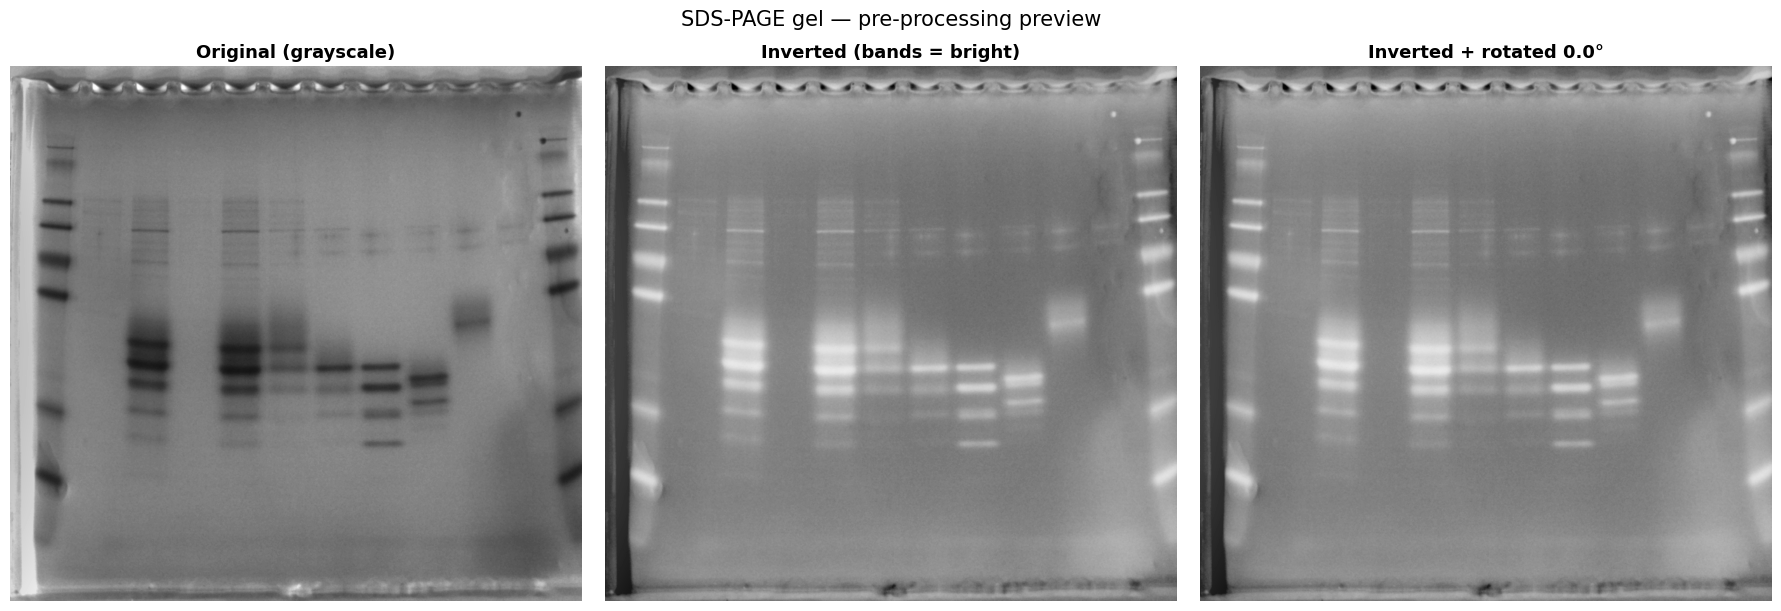

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load image ────────────────────────────────────────────────────────────
IMAGE_PATH = "sample_gel.jpg"

img_bgr  = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"Could not load image at '{IMAGE_PATH}'. "
                            "Check that the file exists and the path is correct.")

# Convert to grayscale (single-channel, 0–255)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ── 2. Invert ─────────────────────────────────────────────────────────────────
# Dark bands on a bright background → bright bands on a dark background.
# This maximises contrast for downstream intensity profiling.
img_inverted = 255 - img_gray

# ── 3. Rotation utility ───────────────────────────────────────────────────────
def rotate_image(image: np.ndarray, angle: float) -> np.ndarray:
    """Rotate *image* by *angle* degrees (counter-clockwise) without cropping.

    The output canvas is expanded so that every corner of the original image
    remains visible; empty regions are filled with black (0).

    Parameters
    ----------
    image : np.ndarray
        Grayscale or colour image array.
    angle : float
        Rotation angle in degrees (positive = counter-clockwise).

    Returns
    -------
    np.ndarray
        Rotated image with the same dtype as the input.
    """
    h, w = image.shape[:2]
    cx, cy = w / 2.0, h / 2.0

    # Build the 2-D rotation matrix around the image centre
    M = cv2.getRotationMatrix2D((cx, cy), angle, scale=1.0)

    # Compute the new bounding dimensions after rotation so no pixels are lost
    cos_a = abs(M[0, 0])
    sin_a = abs(M[0, 1])
    new_w = int(h * sin_a + w * cos_a)
    new_h = int(h * cos_a + w * sin_a)

    # Shift the rotation matrix to account for the expanded canvas
    M[0, 2] += (new_w / 2.0) - cx
    M[1, 2] += (new_h / 2.0) - cy

    return cv2.warpAffine(image, M, (new_w, new_h),
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=0)


# ── 4. Apply a small rotation (e.g. correcting a slight tilt) ─────────────────
ROTATION_ANGLE = 0.0          # degrees — adjust as needed
img_rotated = rotate_image(img_inverted, ROTATION_ANGLE)

# ── 5. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

panels = [
    (img_gray,     "Original (grayscale)",           "gray"),
    (img_inverted, "Inverted (bands = bright)",       "gray"),
    (img_rotated,  f"Inverted + rotated {ROTATION_ANGLE}°", "gray"),
]

for ax, (data, title, cmap) in zip(axes, panels):
    ax.imshow(data, cmap=cmap, vmin=0, vmax=255)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")

fig.suptitle("SDS-PAGE gel — pre-processing preview", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Lane Detector

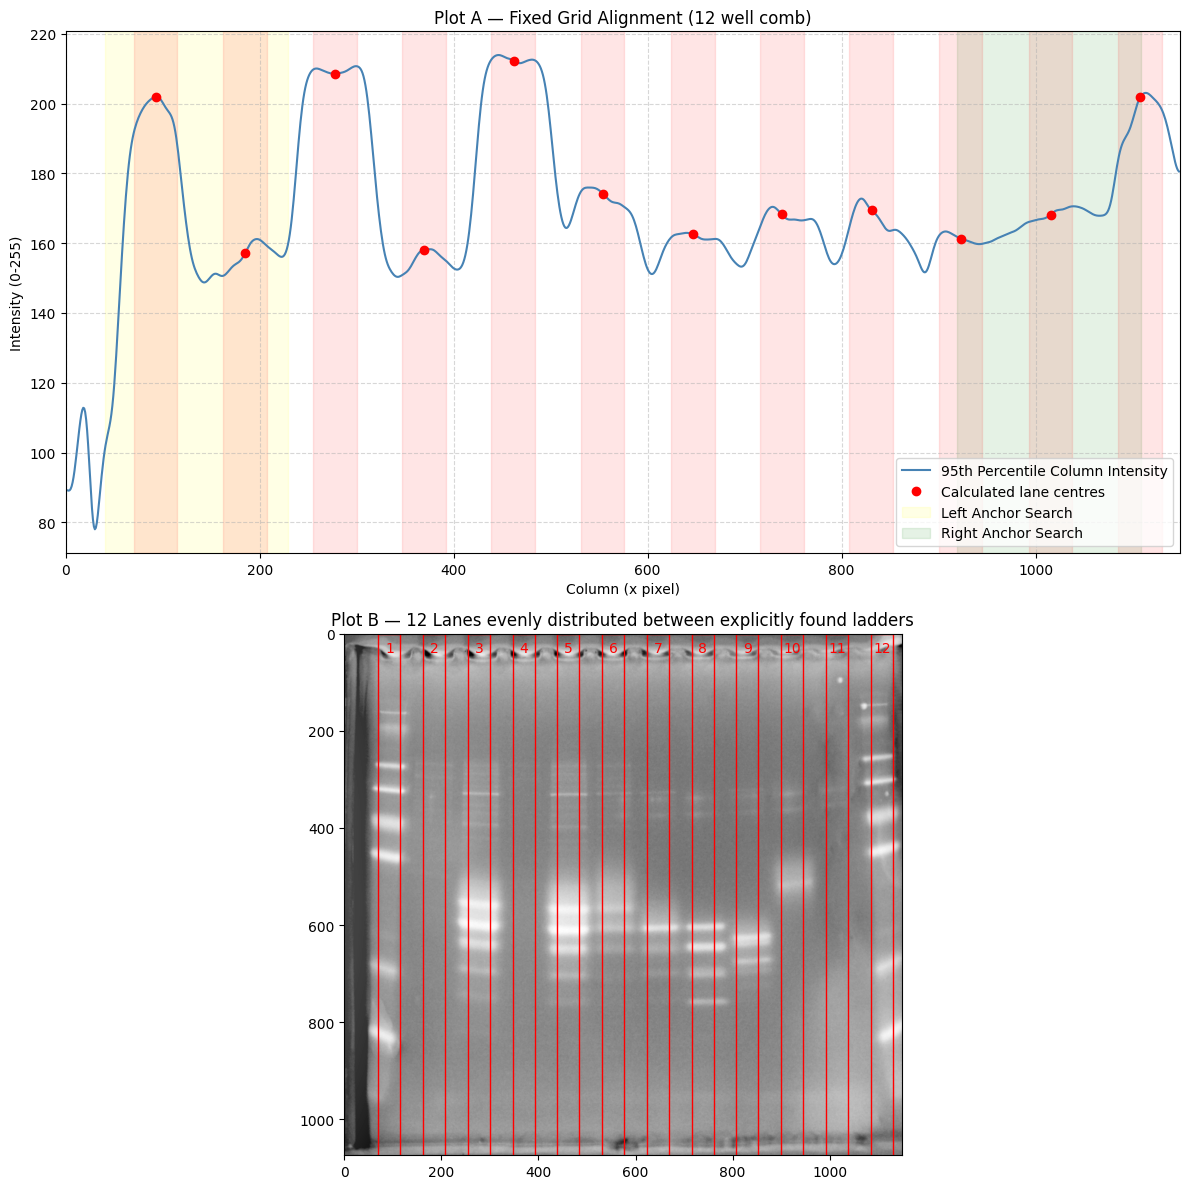

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.ndimage import gaussian_filter1d

# --- CONFIGURABLE PARAMETERS ---
num_wells = 12         # Tell the software the physical comb size
lane_width = 45        # Width of the bounding box
margin = 40            # Ignore the extreme edges
# -------------------------------

width = processed_gel.shape[1]

# 1. Projection Math (95th percentile)
projection = np.percentile(processed_gel, 95, axis=0) 
smoothed_projection = gaussian_filter1d(projection, sigma=4)

# 2. Robust Ladder Detection (Explicit anchors)
# Define regions to search for ladders (first 20% and last 20% of image)
left_search_boundary = int(width * 0.20)
right_search_boundary = int(width * 0.80)

# Find the peak in the left region
left_region = smoothed_projection[margin:left_search_boundary]
left_ladder = np.argmax(left_region) + margin

# Find the peak in the right region
right_region = smoothed_projection[right_search_boundary:(width - margin)]
right_ladder = np.argmax(right_region) + right_search_boundary

# 3. The "Comb Alignment" Magic
# Mathematically distribute the 12 wells evenly between the two ladders
lane_centers = np.linspace(left_ladder, right_ladder, num_wells)

# 4. Calculate bounding boxes
lanes_info = []
for p in lane_centers:
    left = int(p - (lane_width / 2))
    right = int(p + (lane_width / 2))
    lanes_info.append({'center': p, 'left': left, 'right': right, 'width': lane_width})

# --- VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Plot A: The 1D Profile
ax1.plot(smoothed_projection, label='95th Percentile Column Intensity', color='steelblue')
ax1.plot(lane_centers, smoothed_projection[lane_centers.astype(int)], "ro", label='Calculated lane centres')

# Highlight the search areas for debugging
ax1.axvspan(margin, left_search_boundary, color='yellow', alpha=0.1, label='Left Anchor Search')
ax1.axvspan(right_search_boundary, width-margin, color='green', alpha=0.1, label='Right Anchor Search')

for lane in lanes_info:
    ax1.axvspan(lane['left'], lane['right'], color='red', alpha=0.1)
    
ax1.set_title(f"Plot A — Fixed Grid Alignment ({num_wells} well comb)")
ax1.set_xlabel("Column (x pixel)")
ax1.set_ylabel("Intensity (0-255)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xlim(0, width)

# Plot B: Overlaid on Gel
ax2.imshow(processed_gel, cmap='gray')
for idx, lane in enumerate(lanes_info):
    rect = patches.Rectangle((lane['left'], 0), lane['width'], processed_gel.shape[0], 
                             linewidth=1, edgecolor='r', facecolor='none')
    ax2.add_patch(rect)
    ax2.text(lane['center'], 15, str(idx + 1), color='red', ha='center', va='top', fontsize=10)

ax2.set_title(f"Plot B — {num_wells} Lanes evenly distributed between explicitly found ladders")
plt.tight_layout()
plt.show()